In [1]:
import os
os.chdir("..")

In [ ]:
from src.data.cwru_data import cwru_read_mat, cwru_read_normal
from src.utils.utils import sliding_window

from scipy.signal import resample_poly
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import pandas as pd
from scipy.stats import kurtosis, skew
from scipy.signal import hilbert, butter, filtfilt
import scipy.stats as stats
from scipy.signal import stft
import pywt

In [3]:
fault_path = r"D:\Capstone\dataset\raw\CWRU\12k_Drive_End_Bearing_Fault_Data"
normal_path = r"D:\Capstone\dataset\raw\CWRU\Normal"
fanend_path = r"D:\Capstone\dataset\raw\CWRU\12k_Fan_End_Bearing_Fault_Data"

fault = cwru_read_mat(fault_path)
normal = cwru_read_normal(normal_path)
fault_fe = cwru_read_mat(fanend_path)

In [4]:
OR_files, IR_files, B_files, N_files = 0, 0, 0, 0

for root, dirs, files in os.walk(fault_path):
    if "OR" in root:
        for file in files:
            if file.endswith(".mat"):
                OR_files += 1
    elif "IR" in root:
        for file in files:
            if file.endswith(".mat"):
                IR_files += 1
    elif "B" in root:
        for file in files:
            if file.endswith(".mat"):
                B_files += 1

for root, dirs, files in os.walk(normal_path):
    for file in files:
        if file.endswith(".mat"):
            N_files += 1

print(f"Number of Outer Race fault files: {OR_files}")
print(f"Number of Inner Race fault files: {IR_files}")
print(f"Number of Ball fault files: {B_files}")
print(f"Number of Normal files: {N_files}")
print(f"Total: {OR_files + IR_files + B_files + N_files}")

Number of Outer Race fault files: 28
Number of Inner Race fault files: 16
Number of Ball fault files: 16
Number of Normal files: 4
Total: 64


In [5]:
normal_list = [normal['97_Normal_0']['X097_DE_time'], normal['98_Normal_1']['X098_DE_time'], normal['99_Normal_2']['X098_DE_time'],
normal['99_Normal_2']['X099_DE_time'], normal['100_Normal_3']['X100_DE_time']]

data_list = [fault['B']['007']['default'], fault['B']['014']['default'], fault['B']['021']['default'], fault['B']['028']['default'],
               fault['IR']['007']['default'], fault['IR']['014']['default'], fault['IR']['021']['default'], fault['IR']['028']['default'],
               fault['OR']['007']['@6'], fault['OR']['007']['@3'], fault['OR']['007']['@12'],
               fault['OR']['014']['default'],
               fault['OR']['021']['@6'], fault['OR']['021']['@3'], fault['OR']['021']['@12']]
data_list_labels = ["B_007", "B_014", "B_021", "B_028",
                    "IR_007", "IR_014", "IR_021", "IR_028",
                    "OR_007_@6", "OR_007_@3", "0R_007_@12",
                    "OR_014_@6",
                    "OR_021_@6", "OR_021_@3", "0R_021_@12"]

def resample_normal(normal_list, label):
    lst = [label]
    for i in normal_list:
        lst.append(resample_poly(i, up=1, down=4).shape[0])
    return lst

def get_data_points(data_list, label):
    lst = [label]
    for file_dict in data_list:
        for key, value in file_dict.items():
            if key.endswith("DE_time"):
                lst.append(value.shape[0])
    return lst

df = pd.DataFrame(columns=["Fault Labels", "0", "1", "2", "3"])
lst = resample_normal(normal_list, "N")
lst[3] = lst[3] + lst[4]
lst.pop(4)
df.loc[0] = lst
for n, (i, j) in enumerate(zip(data_list, data_list_labels)):
    df.loc[n + 1] = get_data_points(i, j)       
df.loc[16] = ["Total", df["0"].sum(), df["1"].sum(), df["2"].sum(), df["3"].sum()]

df

,Fault Labels,0,1,2,3
0,N,60985,120976,242242,121411
1,B_007,122571,121410,121556,121556
2,B_014,121846,122136,121991,122136
3,B_021,121991,121701,122136,122136
4,B_028,120801,121351,120984,120984
5,IR_007,121265,121991,122136,122917
6,IR_014,121846,121846,121846,121701
7,IR_021,122136,121556,121846,121991
8,IR_028,120801,121351,121351,121535
9,OR_007_@6,121991,122426,121410,122571


# Time-domain Analysis

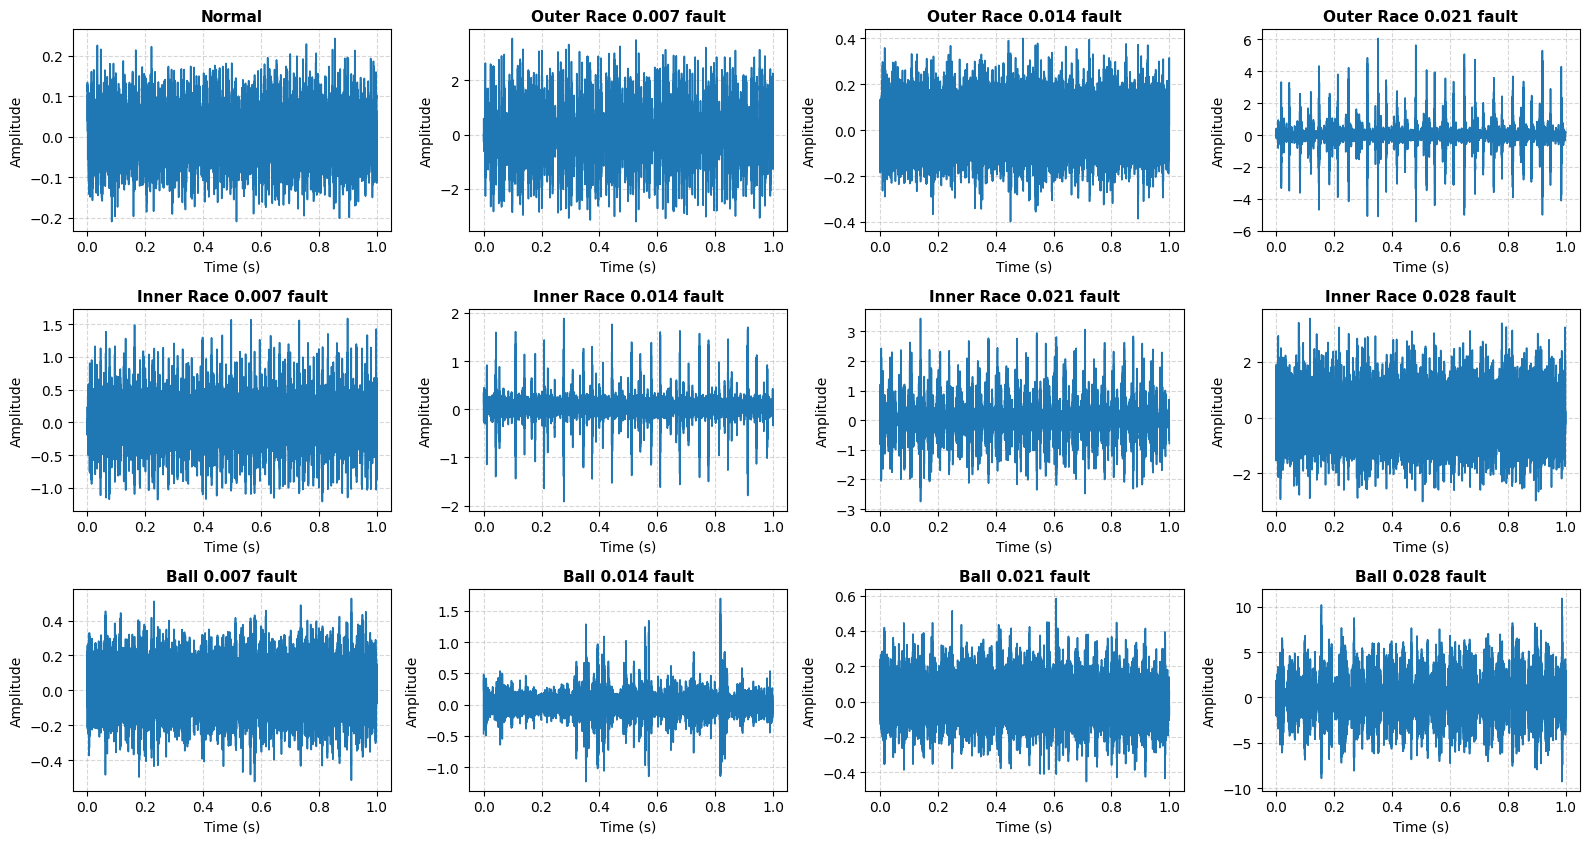

In [6]:
n = normal['100_Normal_3']['X100_DE_time'].squeeze()

or_007 = fault['OR']['007']['@6'][0]['X130_DE_time'].squeeze()
or_014 = fault['OR']['014']['default'][0]['X197_DE_time'].squeeze()
or_021 = fault['OR']['021']["@6"][0]['X234_DE_time'].squeeze()

ir_007 = fault['IR']['007']['default'][0]['X105_DE_time'].squeeze()
ir_014 = fault['IR']['014']['default'][0]['X169_DE_time'].squeeze()
ir_021 = fault['IR']['021']['default'][0]['X209_DE_time'].squeeze()
ir_028 = fault['IR']['028']['default'][0]['X056_DE_time'].squeeze()

b_007 = fault['B']['007']['default'][0]['X118_DE_time'].squeeze()
b_014 = fault['B']['014']['default'][0]['X185_DE_time'].squeeze()
b_021 = fault['B']['021']['default'][0]['X222_DE_time'].squeeze()
b_028 = fault['B']['028']['default'][0]['X048_DE_time'].squeeze()

fault_list = [n, or_007, or_014, or_021, ir_007, ir_014, ir_021, ir_028, b_007, b_014, b_021, b_028]
label_list = ["Normal", "Outer Race 0.007 fault", "Outer Race 0.014 fault", "Outer Race 0.021 fault",
              "Inner Race 0.007 fault", "Inner Race 0.014 fault", "Inner Race 0.021 fault", "Inner Race 0.028 fault",
              "Ball 0.007 fault", "Ball 0.014 fault", "Ball 0.021 fault", "Ball 0.028 fault"]

def plot_signal(fault_list, label_list, n_row=3, n_col=4, N=5000, fs=12000):
    fig, axes = plt.subplots(n_row, n_col, figsize=(16, n_row*3))
    axes = axes.flatten()
    for i, ax in enumerate(axes):
        signal = fault_list[i][:N]
        time = np.arange(N) / fs
        ax.plot(time, signal, linewidth=1.2)
        ax.set_title(label_list[i], fontsize=11, fontweight='bold')
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Amplitude")
        ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_signal(fault_list, label_list, N=12000)

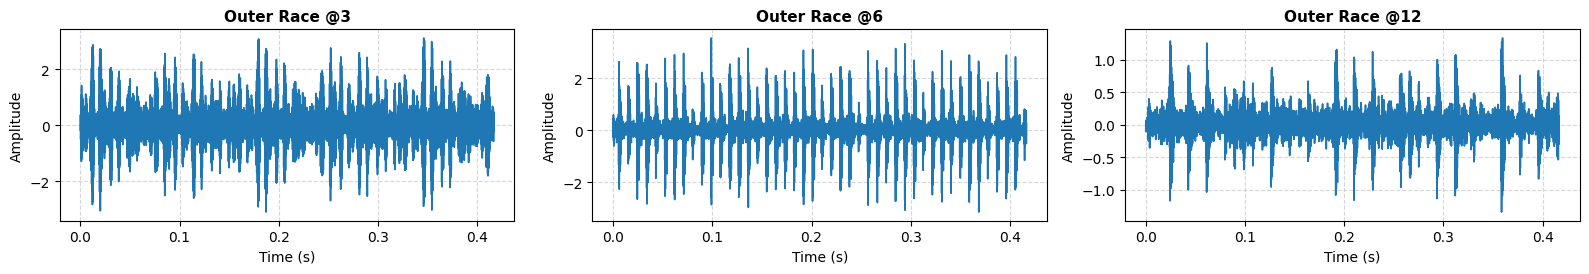

In [7]:
or_007_3 = fault['OR']['007']['@3'][0]['X144_DE_time'].squeeze()
or_007_6 = fault['OR']['007']['@6'][0]['X130_DE_time'].squeeze()
or_007_12 = fault['OR']['007']['@12'][0]['X156_DE_time'].squeeze()

fault_list = [or_007_3, or_007_6, or_007_12]
label_list = ["Outer Race @3", "Outer Race @6", "Outer Race @12"]

plot_signal(fault_list, label_list, n_row=1, n_col=3)

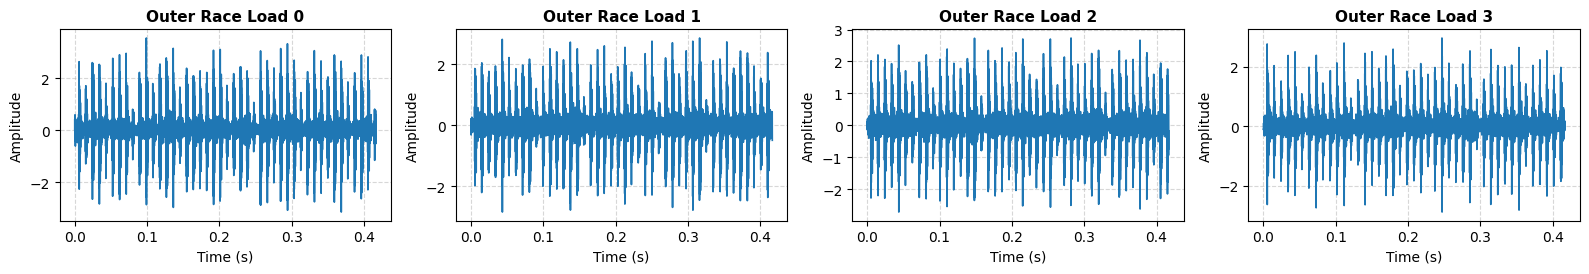

In [8]:
or_007_l1 = fault['OR']['007']['@6'][0]['X130_DE_time'].squeeze()
or_007_l2 = fault['OR']['007']['@6'][1]['X131_DE_time'].squeeze()
or_007_l3 = fault['OR']['007']['@6'][2]['X132_DE_time'].squeeze()
or_007_l4 = fault['OR']['007']['@6'][3]['X133_DE_time'].squeeze()

fault_list = [or_007_l1, or_007_l2, or_007_l3, or_007_l4]
label_list = ["Outer Race Load 0", "Outer Race Load 1", "Outer Race Load 2", "Outer Race Load 3"]

plot_signal(fault_list, label_list, n_row=1, n_col=4)

# Signal Segmentation

In [9]:
b_007_fe = fault_fe['B']['007']['default'][0]['X282_DE_time'].squeeze()
ir_007_fe = fault_fe['IR']['007']['default'][0]['X278_DE_time'].squeeze()
or_007_fe = fault_fe['OR']['007']['@6'][0]['X294_DE_time'].squeeze()
n_fe = normal['100_Normal_3']['X100_FE_time'].squeeze()

In [10]:
fault_list = [or_007, ir_007, b_007, n]

b_007_fe = fault_fe['B']['007']['default'][0]['X282_DE_time'].squeeze()
ir_007_fe = fault_fe['IR']['007']['default'][0]['X278_DE_time'].squeeze()
or_007_fe = fault_fe['OR']['007']['@6'][0]['X294_DE_time'].squeeze()
n_fe = normal['100_Normal_3']['X100_FE_time'].squeeze()
fault_fe_list = [or_007_fe, ir_007_fe, b_007_fe, n_fe]

idx = 50

fault_window_list = [sliding_window(x)[idx] for x in fault_list]
fault_window_fe_list = [sliding_window(x)[idx] for x in fault_fe_list]
label_list = ["Outer Race Fault", "Inner Race Fault", "Ball Fault", "Normal"]

# Time-Domain Analysis

In [11]:
def stats_analysis(fault_window_list, label_list):
    stats_df = pd.DataFrame(columns=['Class', "Mean", "Std Dev", "Min", "Max", 'RMS', 'Peak2Peak', 'Kurtosis', "Skewness", 'Impluse Factor', 'Shape Factor', "Crest Factor"])
    label_list = ['Outer Race', 'Inner Race', 'Ball', 'Normal']
    for signal, cls in zip(fault_window_list, label_list):
        stats = [
            cls,
            np.mean(signal),
            np.std(signal),
            np.min(signal),
            np.max(signal),
            np.sqrt(np.mean(signal**2)),
            np.ptp(signal),
            pd.Series(signal).kurtosis(),
            pd.Series(signal).skew(),
            np.max(np.abs(signal)) / np.mean(np.abs(signal)),
            np.sqrt(np.mean(signal**2)) / np.mean(np.abs(signal)),
            np.max(np.abs(signal)) / np.sqrt(np.mean(signal**2))
        ]
        stats_df.loc[len(stats_df)] = stats
    return stats_df

In [12]:
stats_analysis(fault_window_list, label_list)

,Class,Mean,Std Dev,Min,Max,RMS,Peak2Peak,Kurtosis,Skewness,Impluse Factor,Shape Factor,Crest Factor
0,Outer Race,0.027692,0.666784,-3.181698,3.329514,0.667358,6.511212,4.683930,0.020054,8.166887,1.636948,4.989095
1,Inner Race,0.014174,0.296605,-1.120478,1.473449,0.296944,2.593927,2.149495,0.178793,6.893847,1.389316,4.962044
2,Ball,0.014608,0.148016,-0.395042,0.515732,0.148735,0.910774,-0.292903,-0.019810,4.290034,1.237232,3.467446
3,Normal,0.013495,0.067045,-0.195055,0.265985,0.068390,0.461040,-0.055493,0.014513,4.825984,1.240851,3.889254


In [13]:
stats_analysis(fault_window_fe_list, label_list)

,Class,Mean,Std Dev,Min,Max,RMS,Peak2Peak,Kurtosis,Skewness,Impluse Factor,Shape Factor,Crest Factor
0,Outer Race,0.002333,0.176917,-0.784399,0.856845,0.176933,1.641245,3.407776,0.084369,6.979582,1.441236,4.842776
1,Inner Race,0.002988,0.124834,-0.585416,0.594025,0.124870,1.179441,1.888494,-0.161659,6.250411,1.313895,4.757163
2,Ball,0.003273,0.082847,-0.294820,0.298231,0.082912,0.593051,0.065781,0.070318,4.519977,1.256607,3.596968
3,Normal,0.032050,0.073493,-0.215316,0.271611,0.080178,0.486927,-0.070720,0.025215,4.238135,1.251068,3.387612


# RMS
**Root Mean Square (RMS) represents the effective, average energy content and overall intensity of machine vibration over time.**

**Diagnosis:**
- Healthy bearing -> lower RMS (stable vibration signal).
- Faulty bearing -> higher RMS due to impacts and vibration growth.

**Why important?**
- RMS increases as defect severity increases.
- Good for fault progression monitoring.


# Peak2Peak
**Peak-to-peak (P2P) is the total displacement or distance measured between the maximum positive amplitude and the maximum negative amplitude.**

**Diagnosis:**
- Faults create sharp impacts.
- Impacts increase extreme values → P2P increases.

**Limitation**
- Sensitive to noise.

# Standard Deviation
**Standard deviation ($\sigma$) measures data dispersion around the mean, representing the signal's root-mean-square (RMS) value when the mean is zero.**

**Diagnosis:**
- For zero-mean vibration signals: STD ≈ RMS
- STD increases when vibration variability increases.

# Kurtosis
**Kurtosis is a dimensionless statistical parameter measuring the peakedness or impulsiveness of a signal, acting as a crucial indicator for detecting early-stage machinery faults.**

**Diagnosis:**
- Normal signal → Kurtosis ≈ 3 (Gaussian)
- Faulty bearing → Kurtosis > 3

*Because bearing defects produce periodic impacts.*

**Why Important?**
- Detects early-stage faults
- Sensitive to impulses even when RMS is still small

# Skewness
**Skewness measures the asymmetry of the signal’s amplitude distribution around its mean**

**Diagnosis:**
- Healthy → close to 0
- Faults may create asymmetrical spikes

*Less important than kurtosis but still useful.*

# Crest Factor
**Crest factor is a dimensionless vibration metric defined as the ratio of peak acceleration to RMS acceleration (Peak/RMS), measuring how "peaky" or impulsive a signal is.**

**Diagnosis:**
- Normal → low crest factor
- Fault → high crest factor (because of impulsive peaks)

*Useful for detecting localized defects.*

# Shape Factor
**The shape factor is a non-dimensional, time-domain feature calculated as the ratio of the Root Mean Square (RMS) value to the mean of the absolute amplitude**

**Diagnosis:**
- Normal vibration → stable shape factor
- Fault → waveform becomes more impulsive

*Less sensitive than crest factor or kurtosis.*

# Impulse Factor
**The Impulse Factor is a time-domain metric calculated as the ratio of the maximum absolute peak amplitude to the mean of absolute values**

**Diagnosis:**
- Very sensitive to small impacts.
- Impulse Factor > Crest Factor
- Good for early defect detection.

## Statistical Distribution per Class

In [14]:
def dist_data(fault_list, label_list):
    data = []
    for signal, label in zip(fault_list, label_list):
        segments = sliding_window(signal)
        for seg in segments:       
            rms = np.sqrt(np.mean(seg**2))
            p2p = np.ptp(seg)
            kurt = kurtosis(seg, fisher=False)
            skew = pd.Series(seg).skew()
            impulse = np.max(np.abs(seg)) / np.mean(np.abs(seg))
            crest = np.max(np.abs(seg)) / rms
            data.append({
                "Class": label,
                "RMS": rms,
                "Peak2Peak": p2p,
                "Kurtosis": kurt,
                "Skewness": skew,
                "ImpulseFactor": impulse,
                "CrestFactor": crest,
            })
    df = pd.DataFrame(data)
    return df

In [15]:
dist_df = dist_data(fault_list, label_list)
dist_fe_df = dist_data(fault_fe_list, label_list)

In [16]:
def box_dist_plot(df, suptitle):
    fig, axes = plt.subplots(2, 3, figsize=(16, 6))
    axes = axes.flatten()
    target = df.columns[1:]
    for i, y in enumerate(target):
        sns.boxplot(ax=axes[i], x="Class", y=y, data=df)
        axes[i].set_title(f"{y} Distribution per Class")
    fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

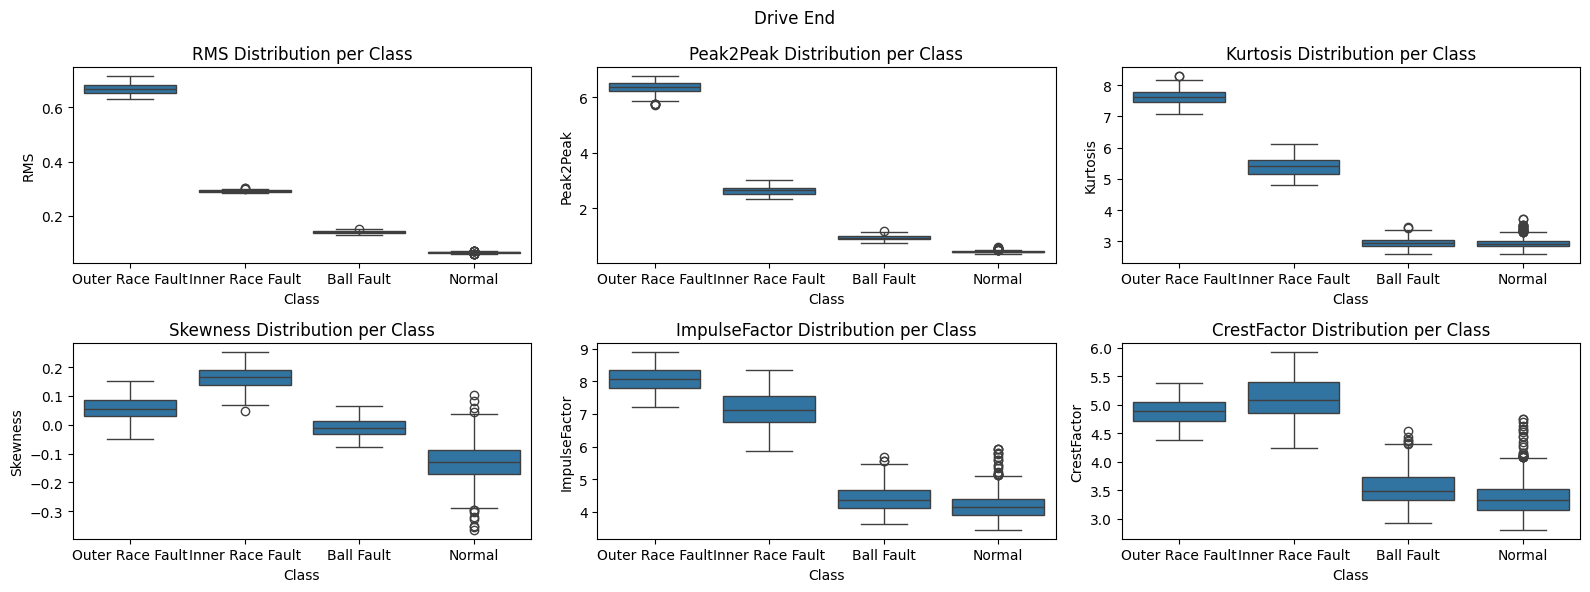

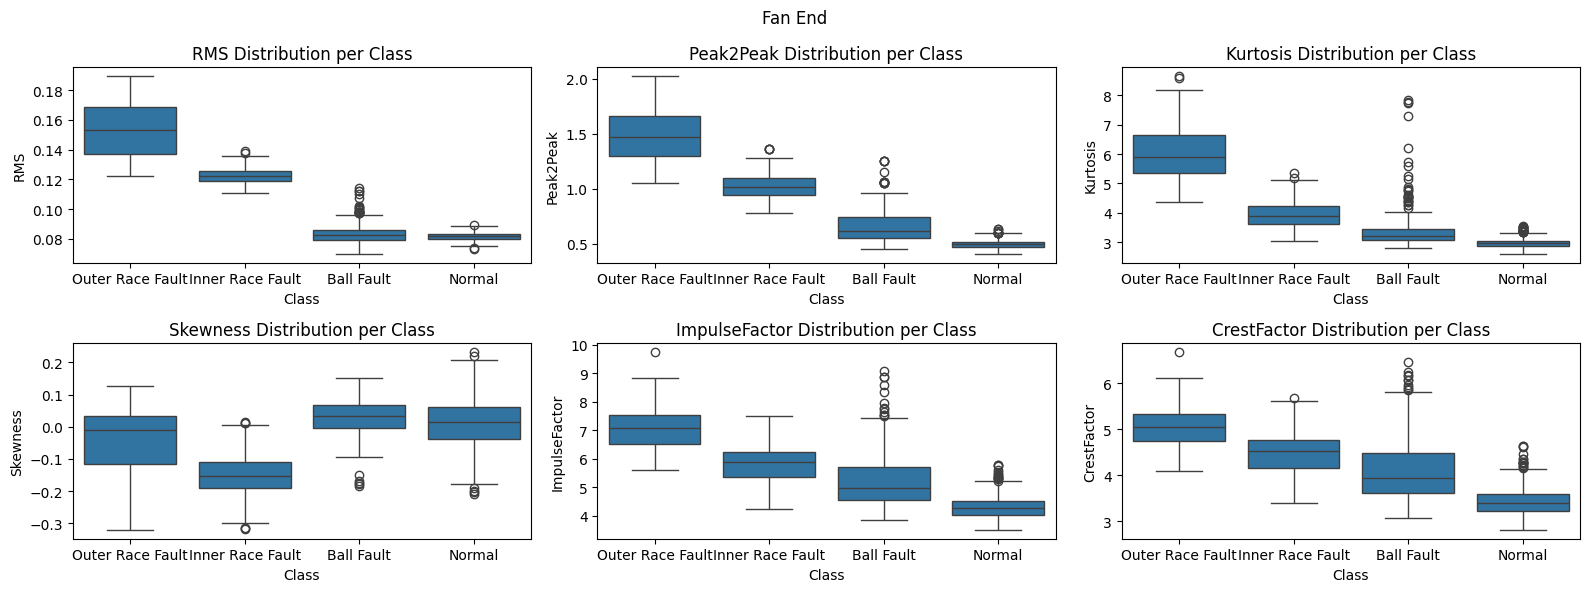

In [17]:
box_dist_plot(dist_df, "Drive End")
box_dist_plot(dist_fe_df, "Fan End")

# Correlation Matrix

In [18]:
def corr_matrix(df):
    corr_matrix = df.corr(numeric_only=True)
    plt.figure(figsize=(10, 10))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        square=True,
        linewidths=0.5
    )
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()

In [19]:
dist_df

,Class,RMS,Peak2Peak,Kurtosis,Skewness,ImpulseFactor,CrestFactor
0,Outer Race Fault,0.671590,6.520958,7.672676,0.132066,8.684596,5.282364
1,Outer Race Fault,0.682007,6.520958,7.515326,0.100177,8.476394,5.201684
2,Outer Race Fault,0.670448,6.520958,7.665612,0.151141,8.793921,5.291363
3,Outer Race Fault,0.685531,6.407660,7.667785,0.067448,7.989054,4.850325
4,Outer Race Fault,0.688396,6.407660,7.720601,0.048550,7.982866,4.830137
...,...,...,...,...,...,...,...
1644,Normal,0.067134,0.442265,3.064976,-0.232223,4.364401,3.502081
1645,Normal,0.067248,0.442265,3.178553,-0.241369,4.376417,3.496179
1646,Normal,0.063352,0.417857,2.937782,-0.141710,4.540638,3.641993
1647,Normal,0.065224,0.453947,3.158076,-0.080728,4.450809,3.537500


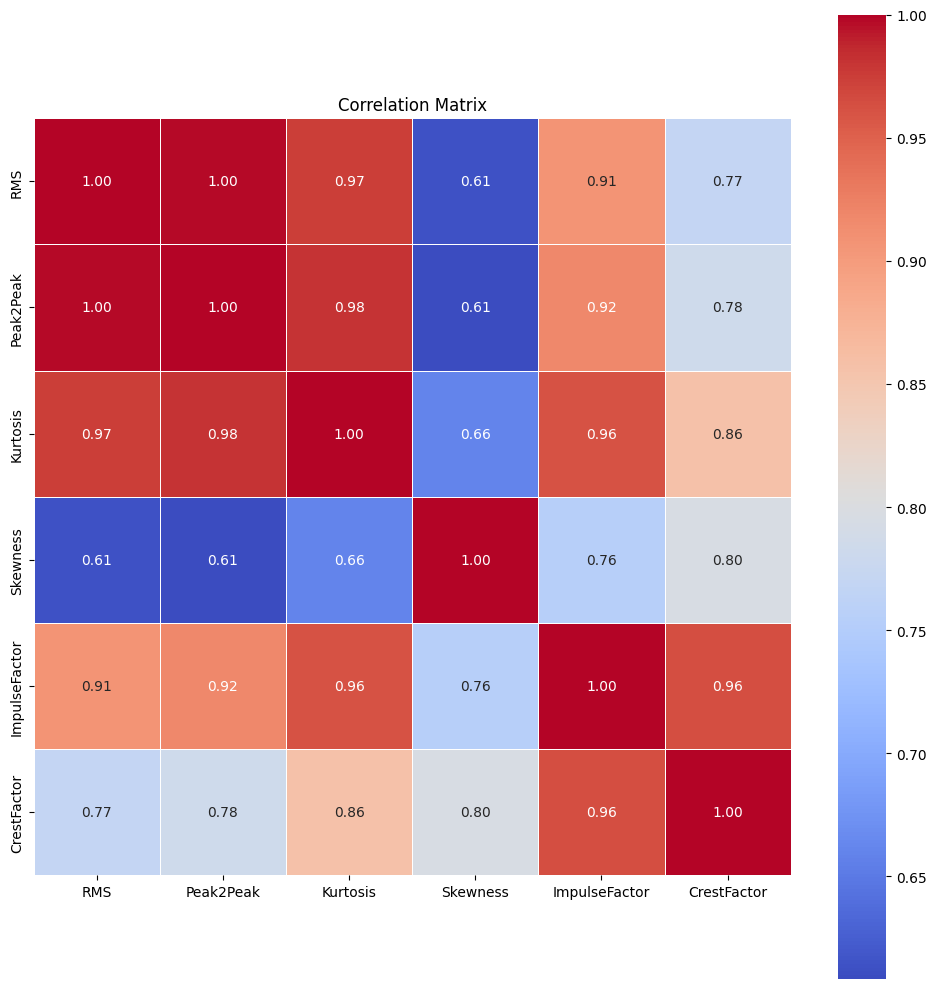

In [20]:
corr_matrix(dist_df)

# Frequency-Domain Analysis

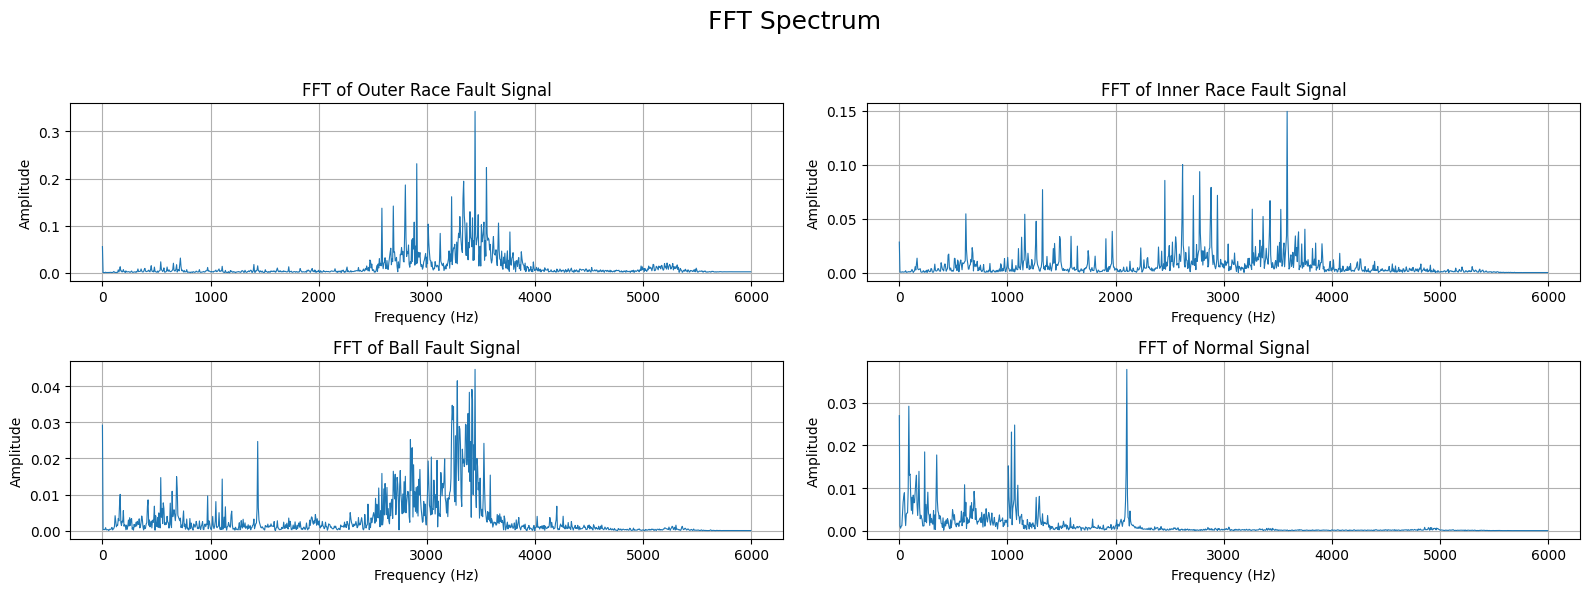

In [21]:
def plot_fft(signal_list, label_list, plot_title, fs=12000):
    fig, axes = plt.subplots(2, 2, figsize=(16, 6))
    axes = axes.flatten()
    n = min(len(signal_list), 4)
    for i in range(n):
        signal = signal_list[i]
        fft_vals = np.fft.fft(signal)
        fft_freq = np.fft.fftfreq(len(signal), 1/fs)
        half = len(signal) // 2
        positive_freq = fft_freq[:half]
        amplitude = np.abs(fft_vals[:half]) * 2 / len(signal)
        axes[i].plot(positive_freq, amplitude, linewidth=0.8)
        axes[i].set_xlabel('Frequency (Hz)')
        axes[i].set_ylabel('Amplitude')
        axes[i].set_title(f'FFT of {label_list[i]} Signal')
        axes[i].grid(True)

    for j in range(n, 4):
        axes[j].set_visible(False)

    fig.suptitle(plot_title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_fft(fault_window_list, label_list, "FFT Spectrum", fs=12000)

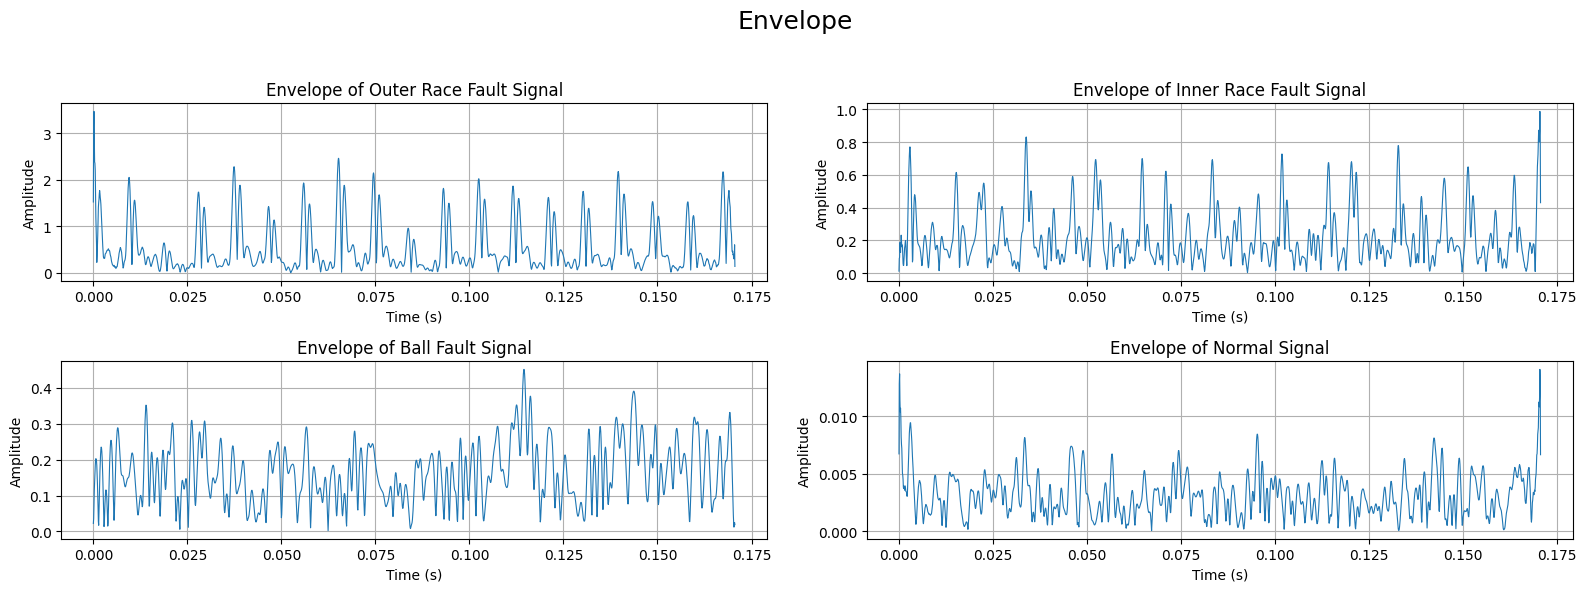

In [22]:
def bandpass_filter(signal, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)


def plot_envelope(signal_list, label_list, plot_title, fs=12000, lowcut=2500, highcut=3500):
    fig, axes = plt.subplots(2, 2, figsize=(16, 6))
    axes = axes.flatten()
    n = min(len(signal_list), 4)

    for i in range(n):
        signal = signal_list[i]
        filtered = bandpass_filter(signal, lowcut, highcut, fs)
        analytic_signal = hilbert(filtered)
        envelope = np.abs(analytic_signal)
        t = np.arange(len(envelope)) / fs

        axes[i].plot(t, envelope, linewidth=0.8)
        axes[i].set_xlabel("Time (s)")
        axes[i].set_ylabel("Amplitude")
        axes[i].set_title(f"Envelope of {label_list[i]} Signal")
        axes[i].grid(True)

    for j in range(n, 4):
        axes[j].set_visible(False)

    fig.suptitle(plot_title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_envelope(fault_window_list, label_list, "Envelope", fs=12000, lowcut=2500, highcut=3500)

In [23]:
np.log1p(1)

0.6931471805599453

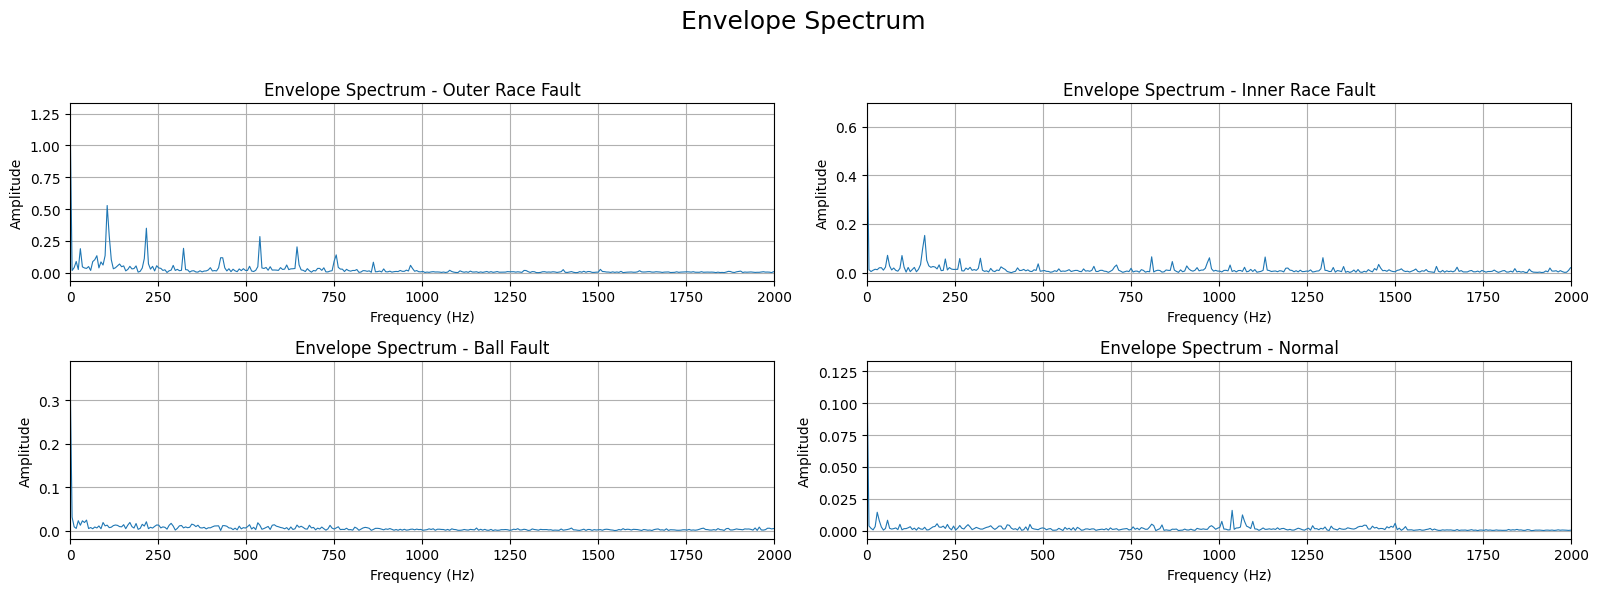

In [24]:
def plot_envelope_spectrum(signal_list, label_list, plot_title, fs=12000,
                                f_low=500, f_high=5000, zoom_freq=2000):
    fig, axes = plt.subplots(2, 2, figsize=(16, 6))
    axes = axes.flatten()
    n = min(len(signal_list), 4)
    for i in range(n):
        signal = signal_list[i]
        b, a = butter(4, [f_low/(fs/2), f_high/(fs/2)], btype='band')
        filtered = filtfilt(b, a, signal)
        analytic_signal = hilbert(filtered)
        envelope = np.abs(analytic_signal)
        N = len(envelope)
        fft_vals = np.fft.fft(envelope)
        freqs = np.fft.fftfreq(N, 1/fs)

        half = N // 2
        positive_freq = freqs[:half]
        amplitude = np.abs(fft_vals[:half]) * 2 / N
        axes[i].plot(positive_freq, amplitude, linewidth=0.8)
        axes[i].set_xlim(0, zoom_freq)
        axes[i].set_xlabel("Frequency (Hz)")
        axes[i].set_ylabel("Amplitude")
        axes[i].set_title(f"Envelope Spectrum - {label_list[i]}")
        axes[i].grid(True)
    for j in range(n, 4):
        axes[j].set_visible(False)

    fig.suptitle(plot_title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

plot_envelope_spectrum(fault_window_list, label_list, "Envelope Spectrum", fs=12000)

# Time-Frequency Analysis

In [25]:
def plot_stft(signal_list, label_list, plot_title, fs=12000):
    fig, axes = plt.subplots(2, 2, figsize=(20, 10))
    axes = axes.flatten()
    n = min(len(signal_list), 4)
    for i in range(n):
        signal = signal_list[i]
        signal = (signal - np.mean(signal)) / (np.std(signal) + 1e-8)
        f, t, Zxx = stft(signal, fs=fs, nperseg=256, noverlap=128)
        spectrogram = np.log1p(np.abs(Zxx))
        spectrogram = (spectrogram - spectrogram.min()) / (spectrogram.max() - spectrogram.min() + 1e-8)
        pcm = axes[i].pcolormesh(t, f, spectrogram, shading='gouraud', cmap='viridis')
        axes[i].set_ylim(0, 6000)
        axes[i].set_xlabel("Time (s)")
        axes[i].set_ylabel("Frequency (Hz)")
        axes[i].set_title(f"STFT - {label_list[i]}")
        axes[i].grid(False)

    for j in range(n, 4):
        axes[j].set_visible(False)

    # fig.colorbar(pcm, ax=axes[:n], shrink=0.6)
    fig.suptitle(plot_title, fontsize=18)
    plt.tight_layout()
    plt.show()

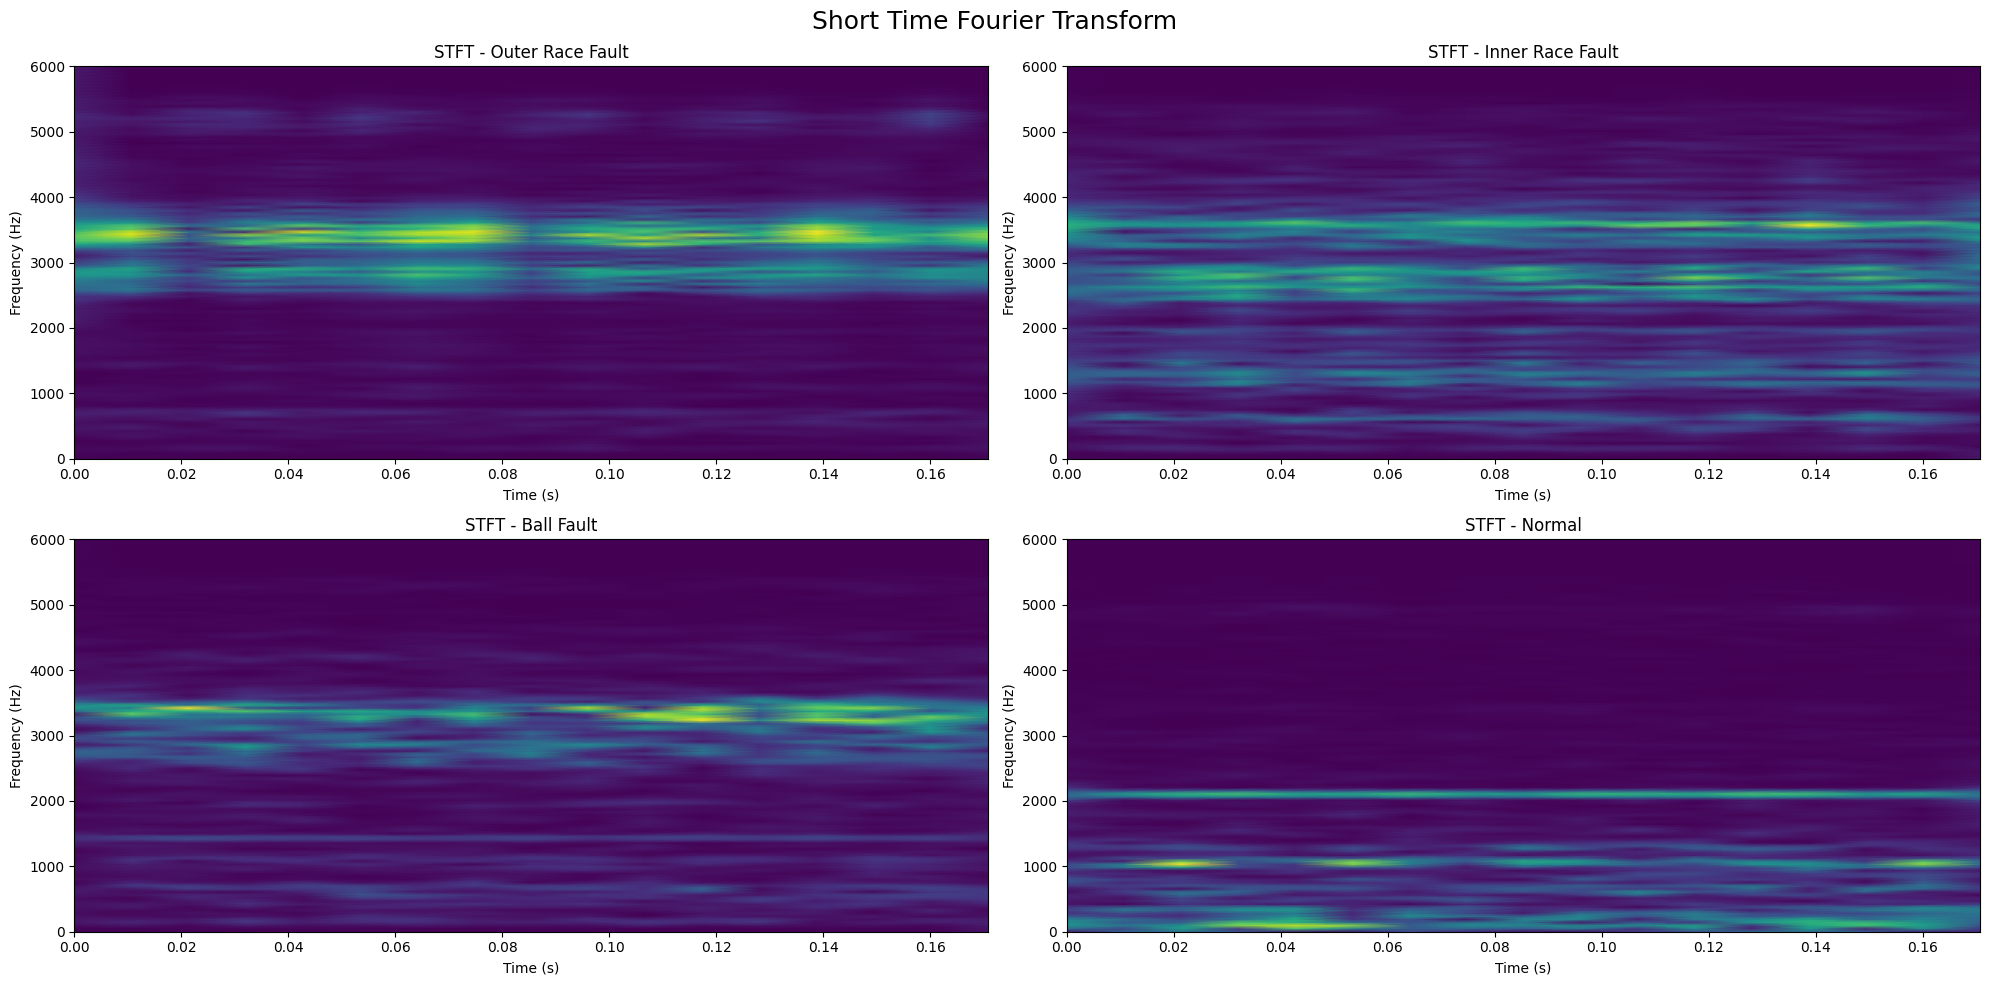

In [26]:
plot_stft(fault_window_list, label_list, "Short Time Fourier Transform")

In [ ]:
def plot_cwt(signal_list, label_list, plot_title, fs=12000):
    fig, axes = plt.subplots(2, 2, figsize=(20, 10))
    axes = axes.flatten()
    n = min(len(signal_list), 4)
    for i in range(n):
        signal = signal_list[i]
        signal = (signal - np.mean(signal)) / (np.std(signal) + 1e-8)
        t = np.arange(len(signal)) / fs
        scales = np.arange(1, 129)
        coeffs, freqs = pywt.cwt(signal, scales, 'morl', sampling_period=1/fs)
        scalogram = np.log1p(np.abs(coeffs))
        scalogram = (scalogram - scalogram.min()) / (scalogram.max() - scalogram.min() + 1e-8)
        pcm = axes[i].pcolormesh(t, freqs, scalogram, shading='gouraud', cmap='viridis')
        axes[i].set_ylim(0, 6000)
        axes[i].set_xlabel("Time (s)")
        axes[i].set_ylabel("Frequency (Hz)")
        axes[i].set_title(f"CWT Scalogram - {label_list[i]}")
        axes[i].grid(False)

    for j in range(n, 4):
        axes[j].set_visible(False)
    # fig.colorbar(pcm, ax=axes, location='right', shrink=0.8, label="Normalized Amplitude")

    fig.suptitle(plot_title, fontsize=18)

    plt.tight_layout(rect=[0,0,0.95,0.95])
    plt.show()

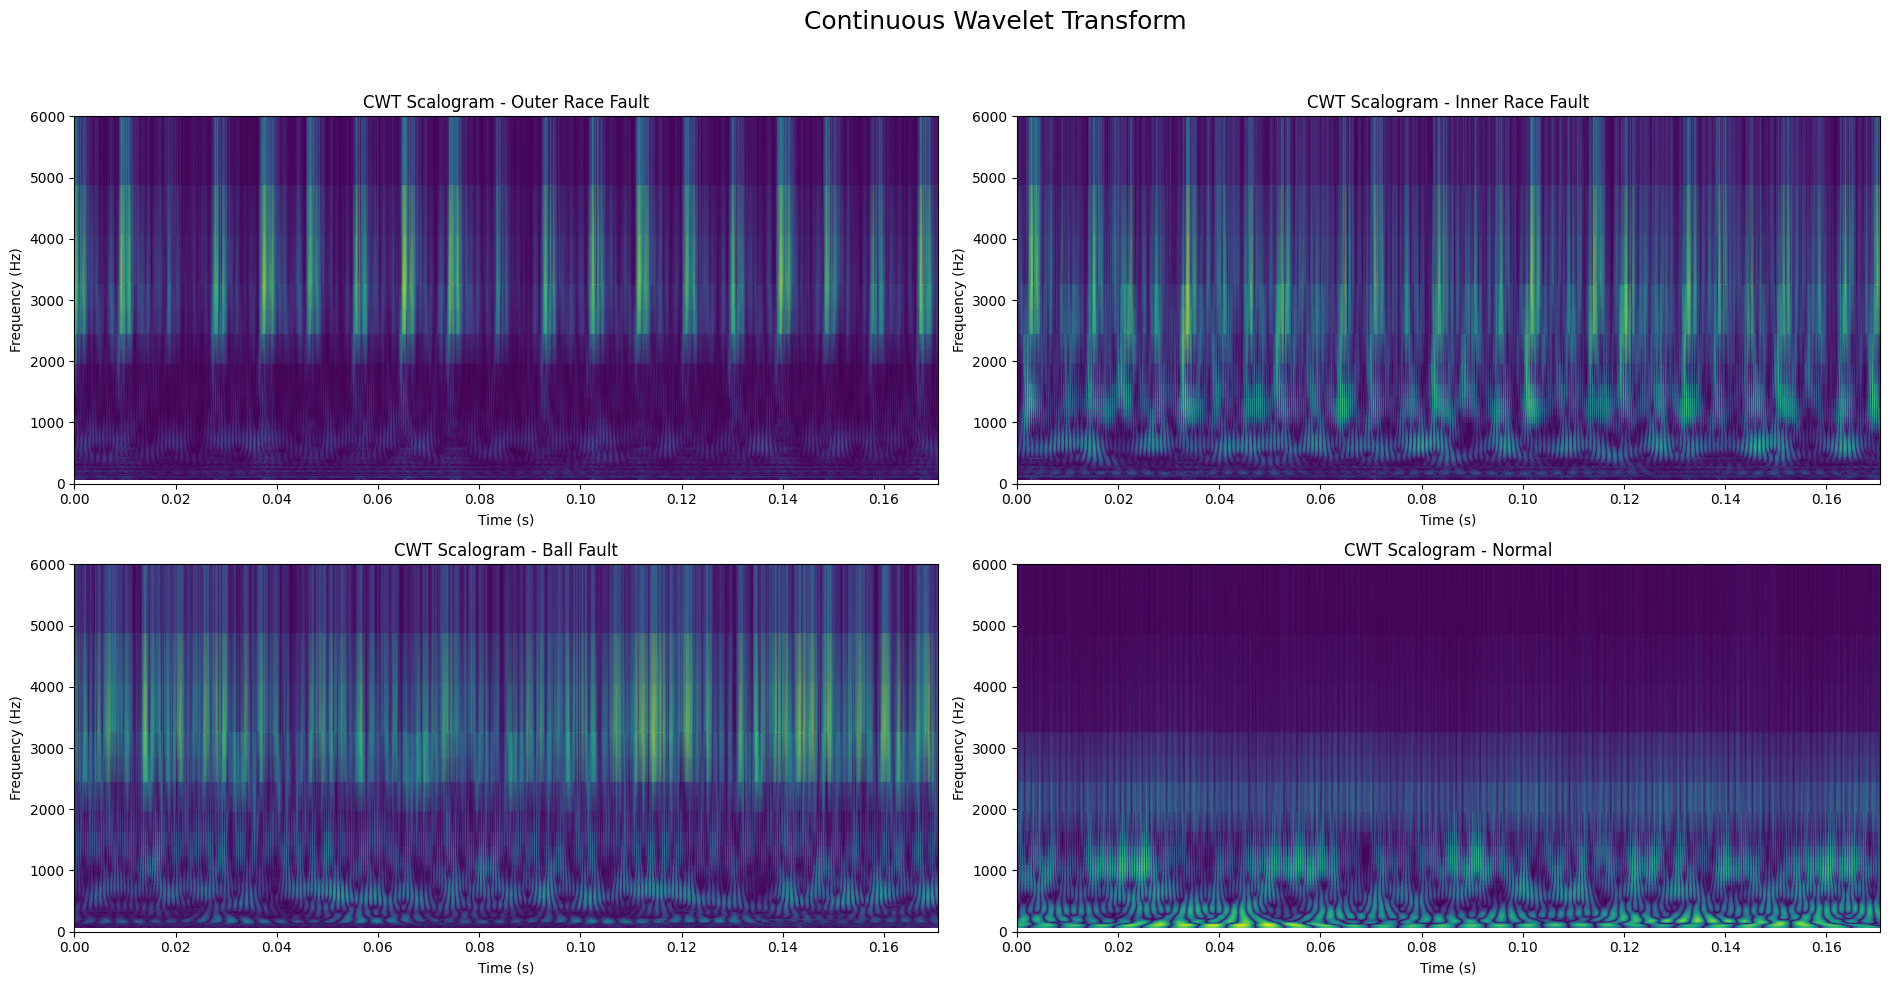

In [28]:
plot_cwt(fault_window_list, label_list, "Continuous Wavelet Transform")